<a href="https://colab.research.google.com/github/mohsinam-afk/Sprint-1---Microscopic-cell-counting-/blob/main/Copy_of_improved_model_reported.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

WELCOME TO MY SPRINT 1 WORKBOOK2(Improved Model)

This sections loads the requied libraries and the datset is downloaded in the cloud from the URL of the dataset directly



In [2]:
import os
import glob
import cv2
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt
import re

#1. Download the dataset from the real direct data URL
print("Downloading the BBBC005 1.8GB archive from the Broad Institute server...")
# Note: The data file sits on the data subdomain, not the main bbbc site
DATA_URL = "https://data.broadinstitute.org/bbbc/BBBC005/BBBC005_v1_images.zip"
!wget -O /content/BBBC005_v1_images.zip "{DATA_URL}"

#2. Extract the downloaded dataset into temporary cloud memory
print("Extracting images into cloud memory...")
!unzip -q /content/BBBC005_v1_images.zip -d /content/dataset
print("Extraction complete!")

--2026-07-07 10:24:40--  https://data.broadinstitute.org/bbbc/BBBC005/BBBC005_v1_images.zip
Resolving data.broadinstitute.org (data.broadinstitute.org)... 69.173.68.137
Connecting to data.broadinstitute.org (data.broadinstitute.org)|69.173.68.137|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1882973059 (1.8G) [application/zip]
Saving to: ‘/content/BBBC005_v1_images.zip’

/content/BBBC005_v1 100%[===================>]   1.75G   103MB/s    in 26s     

2026-07-07 10:25:07 (68.5 MB/s) - ‘/content/BBBC005_v1_images.zip’ saved [1882973059/1882973059]

Extracting images into cloud memory...
Extraction complete!


This section verifies the images are stored on corect folders and a patch of images are used to test the logic, we can change the patch from 0 to 19199 to include the whole dataset where start index specifies the index of image selected and patch specifeis number of images in the patch

example start index: 800 and patch size= 15

In [3]:
# 3. Verify the images are stored on corect folders  and a patch of images are used to test the logic
#There are 19200 images in the dataset starting from index 0 to 19199
dataset_dir = "/content/dataset/BBBC005_v1_images"
image_paths = sorted(glob.glob(os.path.join(dataset_dir, "*.TIF")))

START_INDEX = 0   #Sets the numerical starting position in the file list (index 800).
PATCH_SIZE = 5000 #Specifies that,I want to look at exactly 15 files in a row.

patch = image_paths[START_INDEX : START_INDEX + PATCH_SIZE] # Uses a Python list slicing to isolate files 800 through 814 for processing.

print(f"\n--- SUCCESS ---")
print(f"Total dataset images found: {len(image_paths)}")
print(f"Your patch contains: {len(patch)} images ready for analysis.")


--- SUCCESS ---
Total dataset images found: 19200
Your patch contains: 5000 images ready for analysis.


In this section counters are intialized to store values to plot and access the model performance

In [4]:
# ======================================================================================
# Counters/initialize the strorage counters/placeholders for results and analysis later
# ======================================================================================
total_images = 0 #Initializes a counter to track how many image files are successfully read.
total_cells = 0 #Initializes a cumulative counter for all cells detected across the entire batch.
sample_plotted = False #ciunter to detect the visual plot is generated only once for the first image.




This section is used to extract all the c field values of the filename which represents the cells and add them to give ground truth cell values of the whole dataset

In [5]:
total_ground_truth_cells = 0
for img_path in image_paths:
    filename = os.path.basename(img_path)
    # Extract the 'C' value from the filename
    match = re.search(r'_C(\d+)_', filename)
    if match:
        ground_truth_cells = int(match.group(1))
        total_ground_truth_cells += ground_truth_cells

print(f"Total Ground Truth Cells in the entire dataset: {total_ground_truth_cells}")

Total Ground Truth Cells in the entire dataset: 924000


Step 1: Select Target Image

A sample image is selected before processing so that the complete detection process can be displayed and checked visually. This image is also used to compare the detected cell count with the actual (ground truth) number of cells.

Step 2: Read Image and Apply Otsu Thresholding

Each image is read in grayscale and converted into a black-and-white image using Otsu thresholding. This automatically separates the cells (foreground) from the background without manually choosing a threshold value.

Step 3: Estimate Cell Size

The binary image is analysed to identify all detected objects. The average size of these objects is calculated to estimate the typical cell size, which is used to guide the next processing steps.

Step 4: Adaptive Kernel Selection

An elliptical kernel is created based on the estimated cell size. Choosing the kernel size automatically allows the algorithm to adapt to images containing cells of different sizes.

Step 5: Morphological Opening

A morphological opening operation is applied to remove small noise, smooth cell boundaries, and separate cells that are only slightly connected.

Step 6: Adaptive Erosion

The algorithm repeatedly applies erosion to improve the separation of touching cells. It keeps the version that detects the highest number of cells and stops automatically when further erosion begins to reduce the cell count, preventing over-processing.

Step 7: Cell Counting and Centroid Detection

The final processed image is labelled to count all detected cells. The centre (centroid) of each detected cell is calculated and marked with a red circle on the original image for visual verification.

Step 8: Display Results and Validation

For the selected sample image, the processing stages are displayed step by step, including the original image, thresholded image, opening result, adaptive erosion result, and final detected cells. The detected cell count is also compared with the ground truth value to calculate the counting error.


--- Analyzing Erosion Iterations for: SIMCEPImages_A07_C27_F1_s13_w1.TIF ---
  -> Iteration 1: Found 27 cell clumps
  -> Iteration 2: Found 27 cell clumps
  -> Iteration 3: Found 26 cell clumps
  [!] Stopping Early: Count dropped from 27 to 26.
  [*] Decision: Selected Iteration 2 with max count of 27


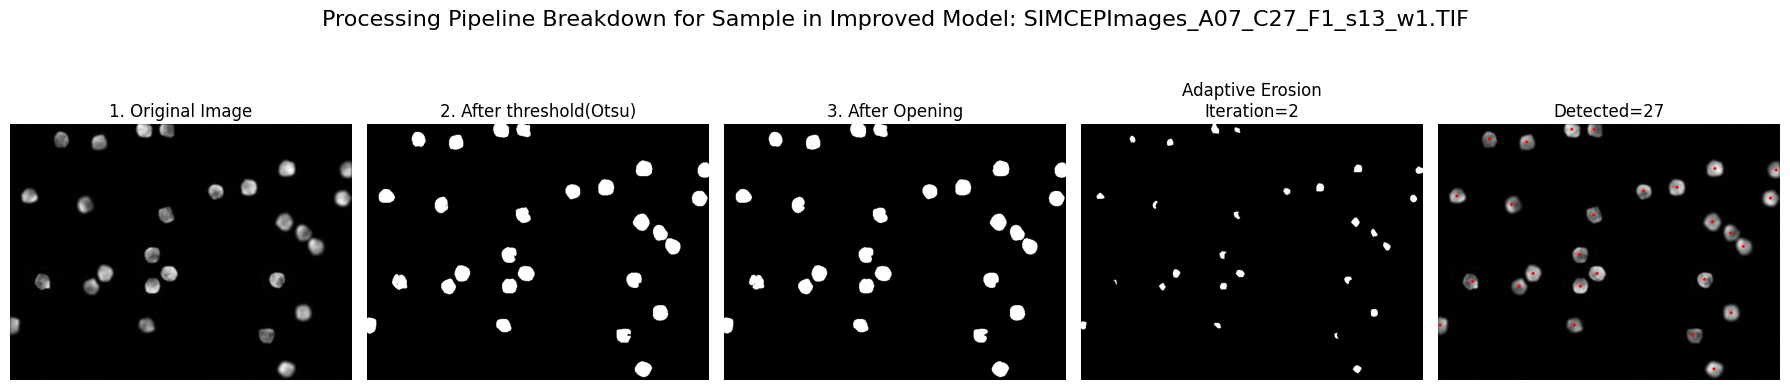


 TARGET SAMPLE VALIDATION METRICS
 Filename Label     : SIMCEPImages_A07_C27_F1_s13_w1.TIF
 Ground Truth Cells : 27
 Model Found Cells  : 27
 Counting Deviation : 0 cells



In [8]:


  # STEP 1 : Target specific file for visual output
target_filename = "SIMCEPImages_A07_C27_F1_s13_w1.TIF"

for img_path in patch:
    filename = os.path.basename(img_path)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Read an image from the selected patch of images and convert it into grayscale.
    total_images += 1     # Increments the image tracker counter by 1.

    # ======================================================
    # STEP 2 : Otsu Threshold
    # ======================================================
    _, binary = cv2.threshold(
         img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    # ======================================================
    # STEP 3 : Estimate Average Foreground Object Size
    # ======================================================
    labels, nlabels = ndimage.label(binary)
    object_sizes = []
    for i in range(1, nlabels + 1):
        area = np.sum(labels == i)
        if area > 10:
            object_sizes.append(area)

    if len(object_sizes) == 0:
        avg_area = 20
    else:
        avg_area = np.mean(object_sizes)
    # ======================================================
    # STEP 4 : Adaptive Kernel Selection
    # ======================================================
    estimated_diameter = int(np.sqrt(avg_area))
    kernel_size = max(3, estimated_diameter // 3)
    if kernel_size % 2 == 0:
        kernel_size += 1
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE, (kernel_size, kernel_size)
    )
    # ======================================================
    # STEP 5 : Opening
    # ======================================================
    opening = cv2.morphologyEx(
        binary, cv2.MORPH_OPEN, kernel
    )
    # ======================================================
    # STEP 6 : Adaptive Erosion Search with Early Stopping
    # ======================================================
    best_count = 0
    best_image = opening.copy()
    best_iteration = 0
    max_iterations = 6

    # Print the specific filename header ONLY for your target image
    if filename == target_filename:
        print(f"\n--- Analyzing Erosion Iterations for: {filename} ---")

    for itr in range(max_iterations):
        current_iteration_num = itr + 1
        current_erosion = cv2.erode(opening, kernel, iterations=current_iteration_num)
        lbl, count = ndimage.label(current_erosion)

        # Print iteration steps ONLY for your target image
        if filename == target_filename:
            print(f"  -> Iteration {current_iteration_num}: Found {count} cell clumps")

        # 1. Update if we find a better (or equal) maximum split
        if count >= best_count and count > 0:
            best_count = count
            best_image = current_erosion.copy()
            best_iteration = current_iteration_num

        # 2. Early Stopping check
        elif count < best_count:
            if filename == target_filename:
                print(f"  [!] Stopping Early: Count dropped from {best_count} to {count}.")
            break

    if filename == target_filename:
        print(f"  [*] Decision: Selected Iteration {best_iteration} with max count of {best_count}")

    # ======================================================
    # STEP 7 : Final Labelling
    # ======================================================
    labels, nlabels = ndimage.label(best_image)
    total_cells += nlabels
    centroids = ndimage.center_of_mass(
        best_image, labels, np.arange(nlabels)+1
    )

    output = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    for pt in centroids:
        if not np.isnan(pt).any():
            cv2.circle(
                output, (int(pt[1]), int(pt[0])), 3, (0,0,255), -1
            )
    # ======================================================
    # Step 8:  Display one sample exclusively
    # ======================================================
    if filename == target_filename:
        plt.figure(figsize=(18,5))
        plt.subplot(1,5,1)
        plt.imshow(img, cmap='gray')
        plt.title("1. Original Image")
        plt.axis("off")

        plt.subplot(1,5,2)
        plt.imshow(binary, cmap='gray')
        plt.title("2. After threshold(Otsu)")
        plt.axis("off")

        plt.subplot(1,5,3)
        plt.imshow(opening, cmap='gray')
        plt.title("3. After Opening")
        plt.axis("off")

        plt.subplot(1,5,4)
        plt.imshow(best_image, cmap='gray')
        plt.title(f"Adaptive Erosion\nIteration={best_iteration}")
        plt.axis("off")

        plt.subplot(1,5,5)
        plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
        plt.title(f"Detected={nlabels}")
        plt.axis("off")

        plt.suptitle(f"Processing Pipeline Breakdown for Sample in Improved Model: {filename}", fontsize=16, y=0.95)
        plt.tight_layout()
        plt.show()

        # Single Image Ground Truth Extraction Printout
        ground_truth_cells = int(re.search(r'_C(\d+)_', filename).group(1))
        print("\n" + "="*40)
        print(f" TARGET SAMPLE VALIDATION METRICS")
        print("="*40)
        print(f" Filename Label     : {filename}")
        print(f" Ground Truth Cells : {ground_truth_cells}")
        print(f" Model Found Cells  : {nlabels}")
        print(f" Counting Deviation : {abs(nlabels - ground_truth_cells)} cells")
        print("="*40 + "\n")


This code block simply prints a summary for the processed image patch.

In [ ]:
print("="*40)
print("Patch Summary")
print("="*40)
print("Images Processed :", total_images)
print("Total Cells :", total_cells)
print("="*40)

Patch Summary
Images Processed : 5000
Total Cells : 179776
